# Demo

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from amafm import analysis, data_loading, force, ml, preprocessing, selection, visualization

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [3]:
DATA_DIR = '../experiments/0041_002'

In [3]:
# One-command force computation tool
# NOTE: Not usable within a notebook, simply execute it from a shell:
# python force_tool.py ../experiments/0041_002 -t 100 -s phase -d out

### load files of a given experiment

In [4]:
# load all files of an experiment
measurements, calib_params = data_loading.load_data(DATA_DIR)

Loading data from .ibw-files: 100%|██████████| 501/501 [00:29<00:00, 16.87it/s]


In [5]:
# load accepted files of a given experiment from CSV
measurements, calib_params = selection.load_accepted_data(DATA_DIR)

Loading data from .ibw-files: 100%|██████████| 50/50 [00:02<00:00, 19.68it/s]


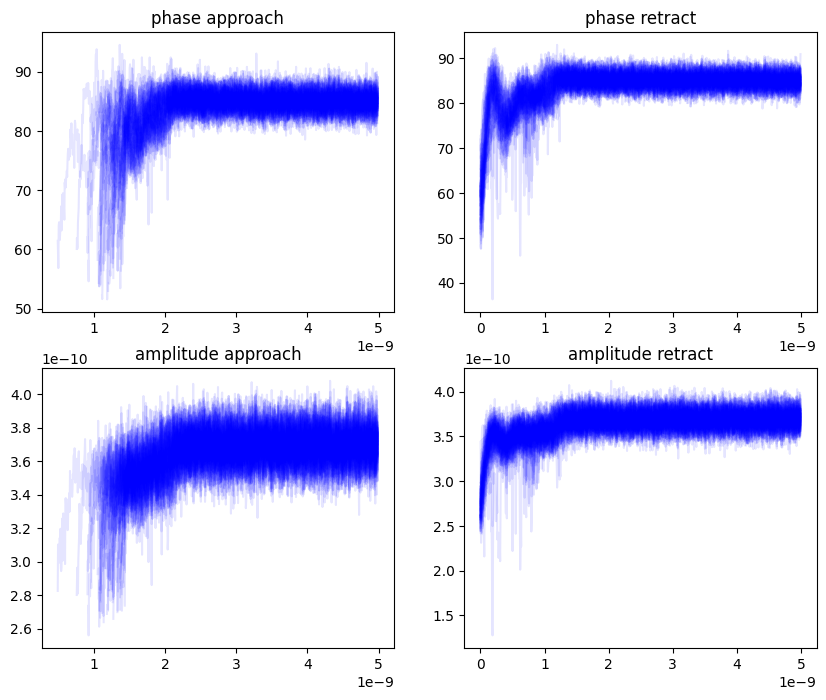

In [7]:
# visualizing all curves
visualization.plot_all(measurements, single_color=True, alpha=0.1)

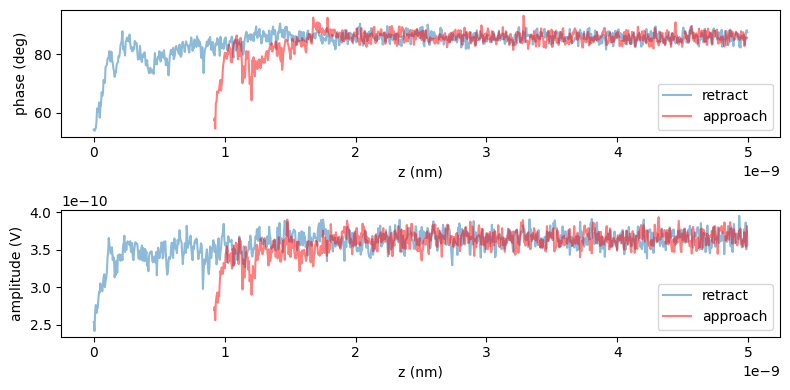

In [8]:
# visualizing: comparing of approach and retract curves
visualization.compare_directions(measurements[0])

### classifying measurements using a machine learning model

Tipp: Try different selection models and inspect the curve plots to select the best selection of measurements.

In [ ]:
# select acceptable measurements
selected_measurements, calib_params = ml.predict(DATA_DIR, model_path='models/RF.joblib', save=False)

> Load data from files for experiment 0041_002...


Loading data from .ibw-files: 100%|██████████| 501/501 [00:27<00:00, 18.13it/s]


> Preprocess measurements...


Step 1/5: Equalize lengths by interpolation:  14%|█▍        | 70/501 [00:00<00:00, 700.00it/s]

   Curves in the file 'C:\OneDrive - AIT\Studium\Master_5. Semester\Interdisciplinary Project\AM-AFM scripts\experiments\0041_002\0041_002Na_100_0233.ibw' are shorter than the desired `reduce_length=512`. Skipping file.


Step 5/5: x-alignment: 100%|██████████| 500/500 [00:00<00:00, 16138.39it/s]


> Found 106 acceptable measurements out of 500.
> Saved classification results to `..\experiments\0041_002\screened_files.csv`.


In [68]:
measurements_processed, _ = preprocessing.preprocess(selected_measurements, calib_params)

Step 4/4: x-alignment: 100%|██████████| 106/106 [00:00<00:00, 15145.50it/s]


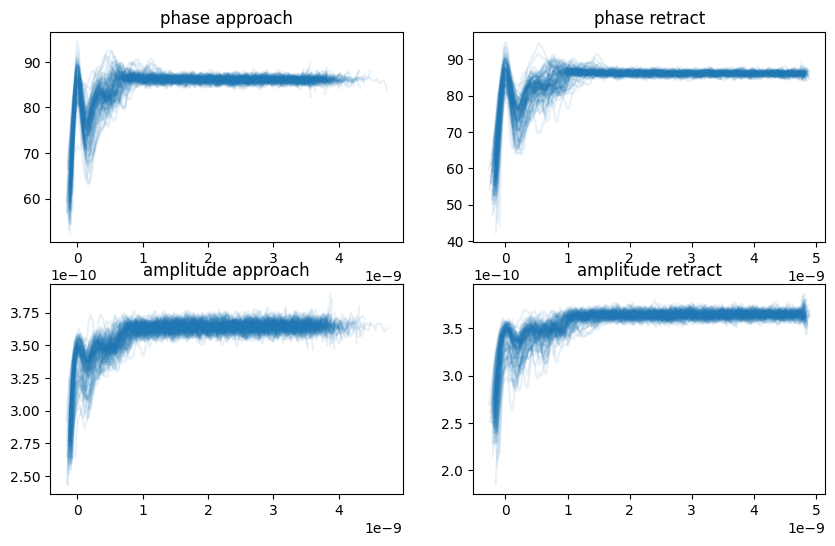

In [77]:
# visualizing preprocessed selected measurements
visualization.plot_all(measurements_processed, single_color=True, alpha=0.1)

### classifying measurements using the manual selection tool

In [ ]:
# NOTE: Not usable within a notebook, simply execute it from a shell:
# python select_experiments.py ../experiments/0041_002 -t 100 -r

### training a classification model

In [ ]:
# re-train a model on new data
data_dir, folder = '../experiments', '0041_002'
data, mct = ml.load_dataset(data_dir, folders=[folder])
models = [
    ml.MODELS['RF'],
]
best_model, results, conf_mats = ml.train_curve_selection_models('RF_new', data, mct, models, cross_val_k=2, test_size=0.1, cutoff=None, 
                                                                 scale=False, inverse_scale=False)

In [ ]:
# train your own models
from sklearn import ensemble

data_dir, folder = '../experiments', '0041_002'
data, mct = ml.load_dataset(data_dir, folders=[folder])
models = [
    (
        ensemble.HistGradientBoostingClassifier,  # model class based on either a sklearn-style estimator or the amafm.ml.NeuralNetworkClassifier
        {
            'random_state': 22,                   # keyword arguments for the model constructor
        }
    ),
    # you can add multiple definitions with different settings to optimize hyperparamters in one step
]
best_model, results, conf_mats = ml.train_curve_selection_models('HistGB', data, mct, models, cross_val_k=2, test_size=0.1, cutoff=None, 
                                                                 scale=False, inverse_scale=False)

In [ ]:
# evaluate model
ml.print_results(results, conf_mats)

### preprocessing curves

In [ ]:
measurements_processed, skipped_idcs = preprocessing.preprocess(measurements, calib_params)

Step 4/4: x-alignment: 100%|██████████| 50/50 [00:00<00:00, 12497.18it/s]


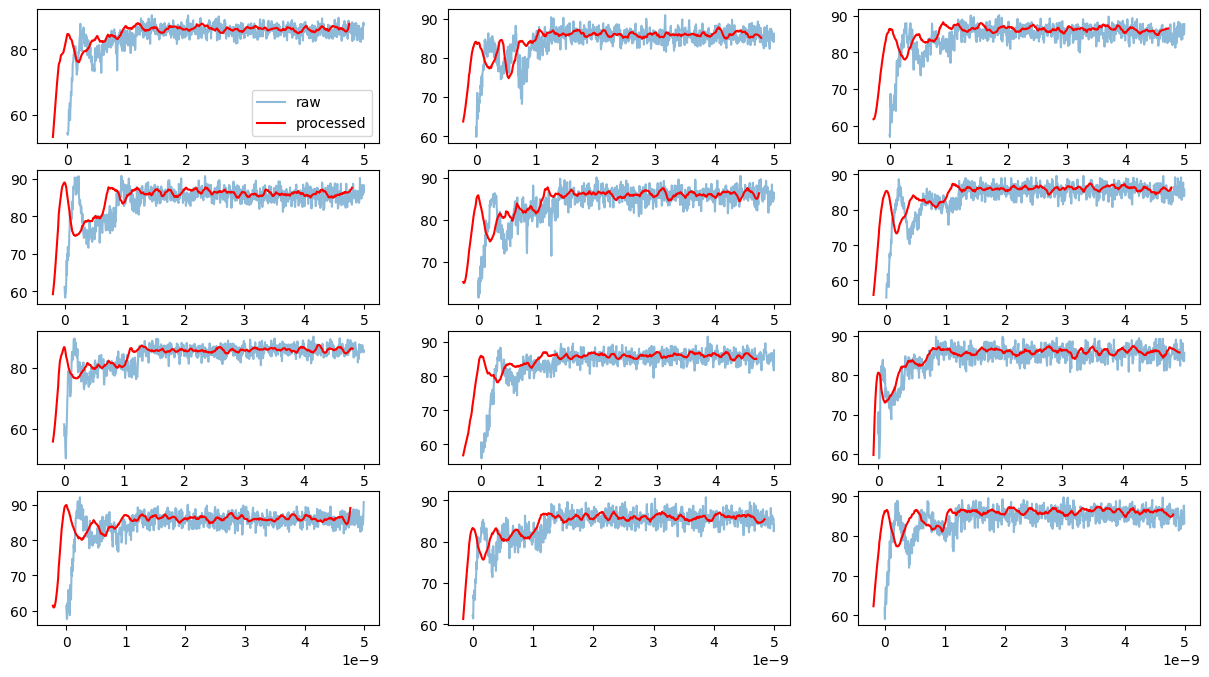

In [11]:
# visualizing: comparing before and after preprocessing
visualization.compare_raw_and_processed(measurements_processed, measurements, signal_type='phase', direction='out', rows=4, columns=3)

### averaging curves

In [12]:
avrg_measurement = analysis.average_curves(measurements_processed)

Average curves for direction='out': 100%|██████████| 50/50 [00:00<00:00, 617.30it/s]


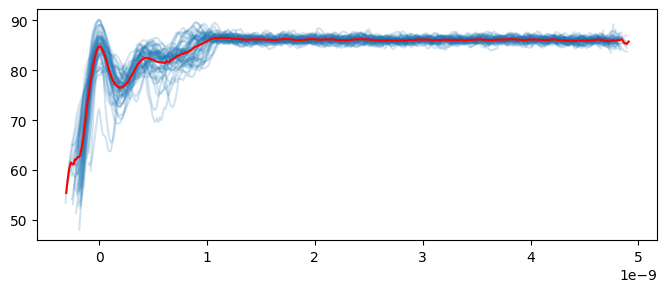

In [13]:
# visualizing: comparing average curve with individual curves
visualization.plot_averaging(avrg_measurement, measurements_processed, signal_type='phase', direction='out')

Average curves for direction='out': 100%|██████████| 50/50 [00:00<00:00, 542.09it/s]


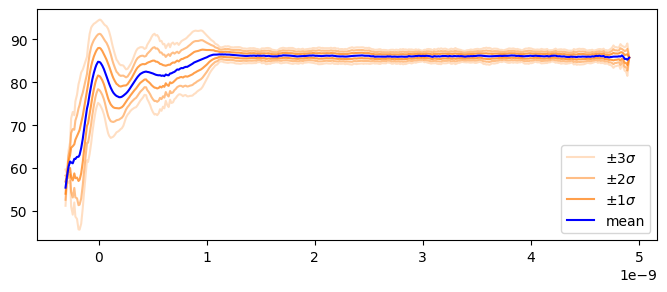

In [ ]:
# using the `zscores` argument the uncertainty in the average curve can be inspected
zscores = [-3, -2, -1, 1, 2, 3]
avrg_measurement, measurements_at_zscores = analysis.average_curves(measurements_processed, n_bins=400, zscores=zscores)
visualization.plot_average_with_uncertainty(avrg_measurement, measurements_at_zscores, zscores=zscores, direction='out', signal_type='phase')

### force calculation

In [16]:
# force calculation
separation, force_curve = force.force_hoelscher(avrg_measurement, calib_params, direction='out')

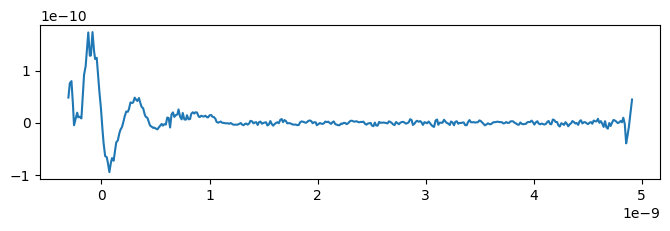

In [15]:
# visualizing force curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 2))
plt.plot(separation, force_curve)
plt.show()

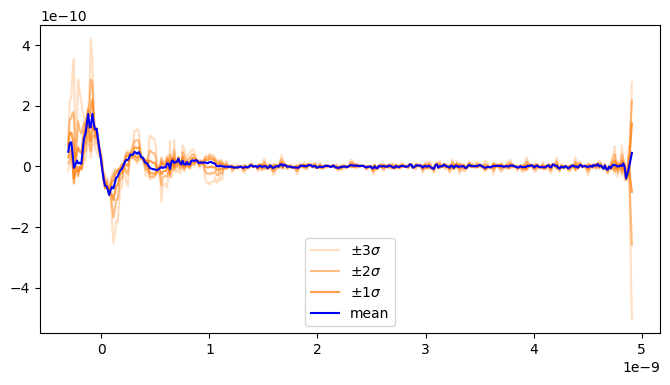

In [20]:
# using the zscore-boundaries of the average curve, the uncertainty in the force curve can be inspected
forces_at_zscores = [force.force_hoelscher(measurement, calib_params) for measurement in measurements_at_zscores]
visualization.plot_force_with_uncertainty((separation, force_curve), forces_at_zscores, zscores=zscores)

### save average and force curves to experiments-folder

In [11]:
analysis.save(avrg_measurement, DATA_DIR)
force.save(separation, force_curve, DATA_DIR)

### load existing average and force curves from experiments-folder

In [4]:
avrg_measurement = analysis.load(DATA_DIR)
separation, force_curve = force.load(DATA_DIR)